<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

00000  var_x=2.817649e-06  vac_E=2.892362e-06  max_amp=2.998685e-02  patch_amp=2.693966e-02  kin_E=2.747575e-11  pot_E=-1.169027e-09  tot_E=-1.141551e-09
00010  var_x=2.272329e-06  vac_E=2.343987e-06  max_amp=2.323369e-02  patch_amp=2.152938e-02  kin_E=6.885992e-10  pot_E=-8.920095e-10  tot_E=-2.034103e-10
00020  var_x=1.400056e-06  vac_E=1.465764e-06  max_amp=1.157566e-02  patch_amp=1.137813e-02  kin_E=1.344252e-09  pot_E=-5.324973e-10  tot_E=8.117542e-10
00030  var_x=7.942164e-07  vac_E=8.532942e-07  max_amp=6.057876e-03  patch_amp=1.245545e-03  kin_E=1.474283e-09  pot_E=-3.684014e-10  tot_E=1.105882e-09
00040  var_x=6.118883e-07  vac_E=6.646007e-07  max_amp=8.120656e-03  patch_amp=6.321934e-03  kin_E=1.229256e-09  pot_E=-4.957603e-10  tot_E=7.334961e-10
00050  var_x=7.086153e-07  vac_E=7.554560e-07  max_amp=1.208487e-02  patch_amp=1.050869e-02  kin_E=9.177596e-10  pot_E=-6.907038e-10  tot_E=2.270558e-10
00060  var_x=8.779766e-07  vac_E=9.195607e-07  max_amp=1.260729e-02  patch_amp=1

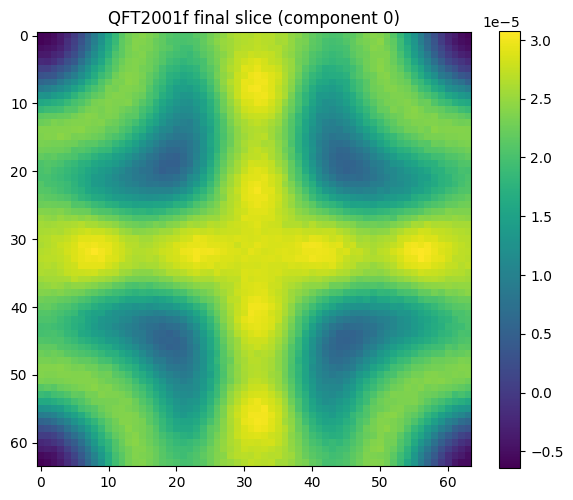

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2001f — Nonlinear Awakening Run
# ============================================================

L = 64
N_int = 100
steps = 2000  # a bit longer to watch nonlinear dynamics

lambda_c = 0.02   # same coupling
gamma    = 0.005  # weaker damping
alpha    = 2.0    # stronger nonlinearity
noise_amp = 5e-5  # tiny symmetry-breaking noise

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------
rng = np.random.default_rng(2026)

x = noise_amp * rng.normal(size=(L, L, L, N_int))

cx = cy = cz = L // 2
X, Y, Z = np.meshgrid(np.arange(L), np.arange(L), np.arange(L), indexing='ij')
R2 = (X - cx)**2 + (Y - cy)**2 + (Z - cz)**2
bump = np.exp(-R2 / (2 * (L/12)**2))

# Stronger initial bump to enter nonlinear regime
x += 0.03 * bump[..., None]

v = np.zeros_like(x)

# ------------------------------------------------------------
# Laplacian
# ------------------------------------------------------------
def laplacian(f):
    return (
        np.roll(f, 1, 0) + np.roll(f, -1, 0) +
        np.roll(f, 1, 1) + np.roll(f, -1, 1) +
        np.roll(f, 1, 2) + np.roll(f, -1, 2) -
        6.0 * f
    )

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
def diagnostics(step, x, v):
    var_x = np.var(x)
    vac_E = np.mean(x**2)
    max_amp = np.max(np.abs(x))
    patch = x[cx-2:cx+3, cy-2:cy+3, cz-2:cz+3]
    patch_amp = np.mean(np.abs(patch))
    kin_E = 0.5 * np.mean(v**2)
    pot_E = 0.5 * lambda_c * np.mean(x * laplacian(x)) + 0.25 * alpha * np.mean(x**4)
    tot_E = kin_E + pot_E
    print(
        f"{step:05d}  var_x={var_x:.6e}  vac_E={vac_E:.6e}  "
        f"max_amp={max_amp:.6e}  patch_amp={patch_amp:.6e}  "
        f"kin_E={kin_E:.6e}  pot_E={pot_E:.6e}  tot_E={tot_E:.6e}"
    )

# ------------------------------------------------------------
# Main evolution loop
# ------------------------------------------------------------
for step in range(steps):
    lap = laplacian(x)
    force = lambda_c * lap - alpha * x**3
    v = (1 - gamma) * v + force
    x = x + v

    if step % 10 == 0:
        diagnostics(step, x, v)

# ------------------------------------------------------------
# Final slice plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.imshow(x[:, :, L//2, 0], cmap='viridis')
plt.colorbar()
plt.title("QFT2001f final slice (component 0)")
plt.tight_layout()
plt.show()
